# Meat and Shrimp Shelf-Life Database Processing

This notebook transforms two raw shelf-life datasets into analysis-ready outputs:

- **Meat database** (`meat_shelf_life.csv`): wide-format records reshaped to long format, column names normalized, missing chemical composition and source values filled via a curated mapping.
- **Shrimp database** (`shrimp_shelf_life.csv`): replicate-level time-series converted to pre/post-threshold summary rows that match the meat schema.

**Output files**
- `data/processed/meat_shelf_life_long.csv`
- `data/processed/shrimp_shelf_life_long.csv`

## Table of Contents

**Meat Database**
1. [Setup and Imports](#1-setup-and-imports)
2. [Load Raw Data](#2-load-raw-data)
3. [Cleaning and Standardization](#3-cleaning-and-standardization)
4. [Missing Value Handling](#4-missing-value-handling)
5. [Export](#5-export)

**Shrimp Database**
6. [Load Raw Data](#6-shrimp-load-raw-data)
7. [Define Thresholds and Ingredient Metadata](#7-define-thresholds-and-ingredient-metadata)
8. [Compute Shelf-Life Indicators](#8-compute-shelf-life-indicators)
9. [Export](#9-shrimp-export)

## 1. Setup and Imports

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

## 2. Load Raw Data

Read the raw meat database CSV into a DataFrame. Dashes (`-`) are treated as missing values.

In [74]:
meatdf = pd.read_csv("data/raw/meat_shelf_life.csv", na_values=["-"])
meatdf.head()

,Article #,ingredient 1,Concentration,Unit of concentration,Normalized concentration % of meat,Chemical composition,source,ingredient 2,Concentration .1,Unit of concentration .1,...,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83
0,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,1.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ANM-0064,anodic NaCl solution,0.0,% (w/w),0.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ANM-0064,anodic NaCl solution,1.0,% (w/w),1.0,Mineral,other natural sources,cathodic NaCl solution,0.0,% (w/w),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
meatdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Article #                              531 non-null    str    
 1   ingredient 1                           531 non-null    str    
 2   Concentration                          452 non-null    float64
 3   Unit of concentration                  446 non-null    str    
 4   Normalized concentration % of meat     531 non-null    float64
 5   Chemical composition                   426 non-null    str    
 6   source                                 438 non-null    str    
 7   ingredient 2                           151 non-null    str    
 8   Concentration .1                       151 non-null    float64
 9   Unit of concentration .1               151 non-null    str    
 10  Normalized concentration %             145 non-null    float64
 11  Chemical composit

## 3. Cleaning and Standardization

Remove trailing empty columns and all-NaN rows, normalize column names to `snake_case`, remove unneeded columns, standardize the information and reshape the wide ingredient layout (up to four ingredient blocks) into a single long-format table.

### 3.1. Remove Unnamed Columns and Empty Rows

In [76]:
meatdf = meatdf.loc[:, ~meatdf.columns.astype(str).str.contains("Unnamed")]
meatdf = meatdf.dropna(how="all")

### 3.2. Normalize Columns

First, normalize column names and make sure all have the appropriate type.

In [77]:
def normalize_column_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
    return df

meatdf = normalize_column_names(meatdf)

meatdf['initial_count'] = pd.to_numeric(meatdf['initial_count'], errors='coerce')
meatdf['post-threshold_day'] = pd.to_numeric(meatdf['post-threshold_day'], errors='coerce')

Next, standardize the information for the `treatment` and `combined_treatment` columns, and drop the now redundant `combined_treatment` alongside `meat_type2`

In [78]:
PATTERNS = {
    "anm": [
        r"\banm\b",
        r"antimicrobial"
    ],
    "map": [
        r"\bmap\b"
    ],
    "salt": [
        r"salt"
    ],
    "heat": [
        r"autoclav",
        r"precook",
        r"cooked"
    ]
}


def standardize_treatment(*values):
    text = " ".join(
        str(v).lower()
        for v in values
        if v and str(v).strip()
    )

    tokens = {
        token
        for token, patterns in PATTERNS.items()
        if any(re.search(p, text) for p in patterns)
    }

    m = re.search(r"irradiation\s*(\d+)", text)
    if m:
        tokens.add(f"irradiation_{m.group(1)}")

    return "+".join(sorted(tokens)) or None


meatdf["treatment"] = meatdf.apply(
    lambda row: standardize_treatment(
        row["treatment"],
        row["combined_treatment"]
    ),
    axis=1
)

meatdf.drop(columns=["combined_treatment", "meat_type_2"], inplace=True)

Many of the numerical columns considered for the meat database could be foregone for now, as they have implicit dependencies/ arbitrary classifications that may influence the final results.
As such, we will only keep the following computed values: 

 - '`initial_inhibition_factor`':  (pre-threshold_count - initial_count) / pre-threshold_day 
 - '`post_inhibition_factor`': (post-threshold_count - pre-threshold_count)/(post-threshold_day- pre-threshold_day)
 - '`post-threshold_proximity_index_1(tpi)`': post-threshold_count/lower_level_threshold

In [ ]:
meatdf.drop(columns=['pre-threshold_proximity_index_1(tpi)','pre-threshold_proximity_index_2(tpi)', 'post-threshold_proximity_index_2(tpi)', 'efficiency', 'efficacite_pre-threshold',  'efficacite_pre-threshold_proximity',  'efficacite_of_post-threshold', 'efficacite_post-threshold_proximity'], inplace=True)

meatdf.rename(columns={'post-threshold_proximity_index_1(tpi)': 'post_threshold_proximity_index'}, inplace=True)

### 3.3. Reshape to Long Format

Each source row contains up to four ingredient blocks (columns `ingredient_1` through `ingredient_4`, each with concentration, unit, normalized concentration, chemical composition, and source). This step unpivots those blocks into one row per ingredient, then drops rows where no ingredient was recorded.

In [80]:
metadata_start = meatdf.columns.get_loc("immersion_time")
metadata_cols = meatdf.columns[metadata_start:]

ingredient_blocks = []

for i in range(1, 5):
    ingredient_blocks.append(
        pd.DataFrame({
            "article_#": meatdf["article_#"],
            "ingredient_id": i,
            "ingredient": meatdf[f"ingredient_{i}"],
            "concentration": meatdf.iloc[:, 1 + (i - 1) * 6 + 1],
            "unit_of_concentration": meatdf.iloc[:, 1 + (i - 1) * 6 + 2],
            "normalized_concentration_%_of_meat": meatdf.iloc[:, 1 + (i - 1) * 6 + 3],
            "chemical_composition": meatdf.iloc[:, 1 + (i - 1) * 6 + 4],
            "source": meatdf.iloc[:, 1 + (i - 1) * 6 + 5],
        }).join(meatdf[metadata_cols])
    )

meatdf_long = (
    pd.concat(ingredient_blocks, ignore_index=True)
      .dropna(subset=["ingredient"])
      .reset_index(drop=True)
)

meatdf = meatdf_long

### 3.4. Normalize String Values

Strip whitespace and lowercase all string columns. Rows with a normalized concentration of 0% are labelled `"control"` before normalization so the label is preserved in lowercase.

In [81]:
def normalize_string_values(df):
    str_cols = df.select_dtypes(exclude="number").columns
    df[str_cols] = df[str_cols].fillna("").apply(lambda s: s.str.strip().str.lower())
    return df

meatdf.loc[
    pd.to_numeric(meatdf["normalized_concentration_%_of_meat"], errors="coerce").eq(0),
    "ingredient"
] = "control"

meatdf = normalize_string_values(meatdf)

## 4. Missing Value Handling

After reshaping, some rows are missing `chemical_composition` or `source`. This section identifies those rows and fills them using a curated ingredient-to-metadata mapping.

### 4.1. Visualize Missing Data Pattern

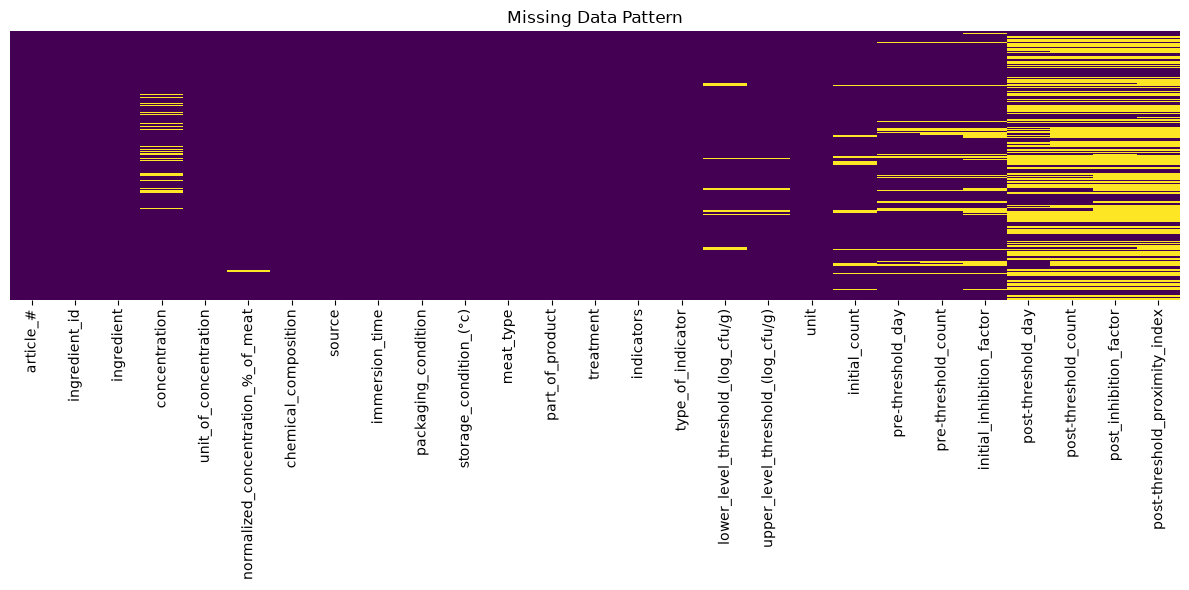

In [82]:
plt.figure(figsize=(12, 6))
sns.heatmap(meatdf.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Data Pattern")
plt.tight_layout()
plt.show()

In [83]:
null_chem_source = meatdf[meatdf["chemical_composition"].isna() | meatdf["source"].isna()]

print("Rows with null chemical_composition or source:", len(null_chem_source))
print("Ingredients affected:", null_chem_source["ingredient"].dropna().unique())

null_chem_source[[
    "article_#",
    "ingredient_id",
    "ingredient",
    "chemical_composition",
    "source"
]].drop_duplicates().sort_values(["ingredient_id", "ingredient"])

Rows with null chemical_composition or source: 0
Ingredients affected: <StringArray>
[]
Length: 0, dtype: str


,article_#,ingredient_id,ingredient,chemical_composition,source


### 4.2. Fill Missing Chemical Composition and Source

Rows whose `ingredient` name matches a key in `INGREDIENT_METADATA` (substring match) receive the corresponding `chemical_composition` and `source` values. Control rows are labelled explicitly.

In [84]:
meatdf.loc[meatdf["ingredient"] == "control", ["chemical_composition", "source"]] = ("none", "none")
meatdf.loc[406, "ingredient"] = "rosemary"

INGREDIENT_METADATA = {
    "chlorine dioxide":         ("mineral",                          "other natural sources"),
    "so2":                      ("mineral",                          "other natural sources"),
    "sodium benzoate":          ("organic acid",                     "other natural sources"),
    "sodium ascorbate":         ("organic acid",                     "plant"),
    "sodium chloride":          ("mineral",                          "other natural sources"),
    "bha/bht":                  ("organic compound (antioxidant)",   "other natural sources"),
    "activin":                  ("polyphenol",                       "plant"),
    "bha":                      ("organic compound (antioxidant)",   "other natural sources"),
    "pycnogenol":               ("polyphenol",                       "plant"),
    "rosemary":                 ("essential oil / polyphenol",       "plant"),
    "stpp":                     ("mineral",                          "other natural sources"),
    "α-tocopherol":             ("vitamin",                          "plant"),
    "alpha-tocopherol":         ("vitamin",                          "plant"),
    "bht":                      ("organic compound (antioxidant)",   "other natural sources"),
    "sodium erythorbate":       ("organic acid",                     "microbial"),
    "nitrate":                  ("mineral",                          "other natural sources"),
    "edta / na2edta":           ("chelating agent (organic compound)", "other natural sources"),
    "edta":                     ("chelating agent (organic compound)", "other natural sources"),
    "thyme oil":                ("essential oil",                    "plant"),
    "turmeric oil":             ("essential oil",                    "plant"),
    "texturized soy":           ("protein",                          "plant"),
    "texturized soya":          ("protein",                          "plant"),
    "pea fi":                   ("fiber",                            "plant"),
}

def is_missing(col):
    return col.isna() | (col.astype(str).str.strip() == "")

ingred = meatdf["ingredient"].astype(str).str.strip().str.lower()
assigned = {"chemical_composition": 0, "source": 0}

for key, (chem_val, src_val) in INGREDIENT_METADATA.items():
    mask = ingred.str.contains(key, na=False, regex=False)
    if not mask.any():
        continue
    chem_mask = mask & is_missing(meatdf["chemical_composition"])
    if chem_mask.any():
        meatdf.loc[chem_mask, "chemical_composition"] = chem_val
        assigned["chemical_composition"] += chem_mask.sum()
    src_mask = mask & is_missing(meatdf["source"])
    if src_mask.any():
        meatdf.loc[src_mask, "source"] = src_val
        assigned["source"] += src_mask.sum()

print(f"Filled {assigned['chemical_composition']} chemical_composition and {assigned['source']} source values.")

remaining = meatdf[is_missing(meatdf["chemical_composition"]) | is_missing(meatdf["source"])]
print(f"Remaining rows with missing values: {len(remaining)}")
if len(remaining):
    display(remaining[["article_#", "ingredient_id", "ingredient", "chemical_composition", "source"]]
            .drop_duplicates().sort_values(["ingredient_id", "ingredient"]))

Filled 45 chemical_composition and 45 source values.
Remaining rows with missing values: 0


## 5. Export

Tag all meat records as theoretically derived (literature values), then write to CSV.

In [85]:
meatdf["data_source"] = "theoretical"

OUTPUT_PATH = "data/processed/meat_shelf_life_long.csv"
meatdf.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(meatdf):,} rows to {OUTPUT_PATH}")

Saved 748 rows to data/processed/meat_shelf_life_long.csv


In [86]:
meatdf.columns

Index(['article_#', 'ingredient_id', 'ingredient', 'concentration',
       'unit_of_concentration', 'normalized_concentration_%_of_meat',
       'chemical_composition', 'source', 'immersion_time',
       'packaging_condition', 'storage_condition_(°c)', 'meat_type',
       'part_of_product', 'treatment', 'indicators', 'type_of_indicator',
       'lower_level_threshold_(log_cfu/g)',
       'upper_level_threshold_(log_cfu/g)', 'unit', 'initial_count',
       'pre-threshold_day', 'pre-threshold_count', 'initial_inhibition_factor',
       'post-threshold_day', 'post-threshold_count', 'post_inhibition_factor',
       'post-threshold_proximity_index', 'data_source'],
      dtype='str')

# Shrimp Database Processing

The shrimp dataset contains replicate-level time-series measurements for four indicators: total viable count (TVC), trimethylamine nitrogen (TMAN), total volatile basic nitrogen (TVBN), and peroxide value (PV). Each replicate-by-indicator series is reduced to pre-threshold and post-threshold summary rows using the same schema as the meat database.

## 6. Load Raw Data

In [87]:
shrimpdf = pd.read_csv("data/raw/shrimp_shelf_life.csv", na_values=["-"])
shrimpdf = normalize_column_names(shrimpdf)
shrimpdf.head()

,replicate,ingredient,day,peroxide_value,total_bacteria_count_log,tvb_n,tma_n
0,1.0,NT,1.0,0.000000,2.501972,0.654640,0.514360
1,2.0,NT,1.0,0.109852,2.464908,2.098021,0.161386
2,3.0,NT,1.0,0.206723,2.515180,0.435595,0.197998
3,1.0,NT,3.0,0.503731,2.829161,0.220075,0.000000
4,2.0,NT,3.0,0.393879,3.046019,0.205595,0.000000


## 7. Define Thresholds and Ingredient Metadata

Specify spoilage thresholds for each indicator and define the ingredient lookup table mapping treatment codes (as used in the raw data) to ingredient details.

In [88]:
# Chemical indicators
SHRIMP_LOW_TMAN = 5
SHRIMP_HIGH_TMAN = 15

SHRIMP_LOW_TVBN = 15
SHRIMP_HIGH_TVBN = 30

SHRIMP_LOW_PV = 5
SHRIMP_HIGH_PV = 10

# Microbial indicators
SHRIMP_LOW_TVC = 5
SHRIMP_HIGH_TVC = 7

indicator_config = {
    "total_bacteria_count_log": {
        "indicator": "tvc",
        "type_of_indicator": "microbial",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TVC,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TVC,
        "unit": "log cfu/g"
    },
    "tma_n": {
        "indicator": "tman",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TMAN,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TMAN,
        "unit": "mg n/100g"
    },
    "tvb_n": {
        "indicator": "tvbn",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_TVBN,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_TVBN,
        "unit": "mg n/100g"
    },
    "peroxide_value": {
        "indicator": "pv",
        "type_of_indicator": "chemical",
        "lower_level_threshold_(log_cfu/g)": SHRIMP_LOW_PV,
        "upper_level_threshold_(log_cfu/g)": SHRIMP_HIGH_PV,
        "unit": "meq o2/kg"
    }
}

ingredients_dict = {
    "NT": {
        "ingredient": "control",
        "ingredient id": 1,
        "concentration": None,
        "unit": None,
        "chemical composition": None,
        "source": None
    },

    "PA": {
        "ingredient": "peracetic acid",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "ppm",
        "chemical composition": "organic acid",
        "source": "other natural sources"
    },

    "N5": {
        "ingredient": "nisin",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "MIC",
        "chemical composition": "protein",
        "source": "microbial"
    },

    "N10": {
        "ingredient": "nisin",
        "ingredient id": 1,
        "concentration": 1000,
        "unit": "MIC",
        "chemical composition": "protein",
        "source": "microbial"
    },

    "PAN": [
        {
            "ingredient": "nisin",
            "ingredient id": 1,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "protein",
            "source": "microbial"
        },
        {
            "ingredient": "peracetic acid",
            "ingredient id": 2,
            "concentration": 250,
            "unit": "ppm",
            "chemical composition": "organic acid",
            "source": "other natural sources"
        }
    ],

    "B5": {
        "ingredient": "brevibacillin",
        "ingredient id": 1,
        "concentration": 500,
        "unit": "MIC",
        "chemical composition": "peptide",
        "source": "microbial"
    },

    "B10": {
        "ingredient": "brevibacillin",
        "ingredient id": 1,
        "concentration": 1000,
        "unit": "MIC",
        "chemical composition": "peptide",
        "source": "microbial"
    },

    "NB": [
        {
            "ingredient": "brevibacillin",
            "ingredient id": 1,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "peptide",
            "source": "microbial"
        },
        {
            "ingredient": "nisin",
            "ingredient id": 2,
            "concentration": 500,
            "unit": "MIC",
            "chemical composition": "protein",
            "source": "microbial"
        }
    ],

    "F3": [
        {
            "ingredient": "sunflower lecithin",
            "ingredient id": 1,
            "concentration": 0.3,
            "unit": "%",
            "chemical composition": "lipid",
            "source": "plant"
        },
        {
            "ingredient": "lime extract",
            "ingredient id": 2,
            "concentration": 9.0,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "lime oil",
            "ingredient id": 3,
            "concentration": 9.5,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        },
        {
            "ingredient": "lemon oil",
            "ingredient id": 4,
            "concentration": 0.5,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        },
        {
            "ingredient": "orange oil",
            "ingredient id": 5,
            "concentration": 1.3,
            "unit": "%",
            "chemical composition": "essential oil",
            "source": "plant"
        }
    ],

    "F4": [
        {
            "ingredient": "garlic extract",
            "ingredient id": 1,
            "concentration": 0.025,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "grape and blueberry",
            "ingredient id": 2,
            "concentration": 0.2,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        },
        {
            "ingredient": "cranberry",
            "ingredient id": 3,
            "concentration": 0.2,
            "unit": "%",
            "chemical composition": "phenol",
            "source": "plant"
        }
    ]
}

## 8. Compute Shelf-Life Indicators

Add study-level metadata columns, then iterate over each ingredient-replicate-indicator combination to compute the last measurement before and first measurement after each spoilage threshold.

In [89]:
def explode_ingredient_metadata(ingredient_code):
    metadata = ingredients_dict[ingredient_code]
    return [metadata] if isinstance(metadata, dict) else metadata


def find_threshold_transition(df, value_col, threshold):
    df = df.sort_values("day")
    below = df[df[value_col] < threshold]
    above = df[df[value_col] >= threshold]

    pre_day = pre_count = post_day = post_count = None

    if not below.empty:
        pre_row = below.iloc[-1]
        pre_day, pre_count = pre_row["day"], pre_row[value_col]

    if not above.empty:
        post_row = above.iloc[0]
        post_day, post_count = post_row["day"], post_row[value_col]

    return pre_day, pre_count, post_day, post_count

In [90]:
records = []

for ingredient_code, ingredient_df in shrimpdf.groupby("ingredient"):
    for ingredient_info in explode_ingredient_metadata(ingredient_code):
        for replicate, replicate_df in ingredient_df.groupby("replicate"):
            for value_col, indicator_info in indicator_config.items():
                working_df = replicate_df[["day", value_col]].dropna()
                if working_df.empty:
                    continue

                pre_day, pre_count, post_day, post_count = find_threshold_transition(
                    working_df,
                    value_col,
                    indicator_info["lower_level_threshold_(log_cfu/g)"],
                )

                initial_count = working_df.sort_values("day").iloc[0][value_col]

                records.append({
                    "article_#":                            None,
                    "ingredient_id":                        ingredient_info["ingredient id"],
                    "ingredient":                           ingredient_info["ingredient"],
                    "concentration":                        ingredient_info["concentration"],
                    "unit_of_concentration":                ingredient_info["unit"],
                    "normalized_concentration_%_of_meat":   None,
                    "chemical_composition":                 ingredient_info["chemical composition"],
                    "source":                               ingredient_info["source"],
                    "immersion_time":                       None,
                    "packaging_condition":                  None,
                    "storage_condition_(°c)":               4,
                    "meat_type":                            "shrimp",
                    "part_of_product":                      "whole",
                    "treatment":                            "anm+heat",
                    "indicators":                           indicator_info["indicator"],
                    "type_of_indicator":                    indicator_info["type_of_indicator"],
                    "lower_level_threshold_(log_cfu/g)":    indicator_info["lower_level_threshold_(log_cfu/g)"],
                    "upper_level_threshold_(log_cfu/g)":    indicator_info["upper_level_threshold_(log_cfu/g)"],
                    "unit":                                 indicator_info["unit"],
                    "initial_count":                        initial_count,
                    "pre-threshold_day":                    pre_day,
                    "pre-threshold_count":                  pre_count,
                    "post-threshold_day":                   post_day,
                    "post-threshold_count":                 post_count,
                    "data_source":                          "experimental",
                })

print(f"Built {len(records):,} records.")

Built 216 records.


In [91]:
def compute_inhibition_features(df):
    """Compute inhibition features for shelf-life prediction."""
    return df.assign(
        # Protect against division by zero (pre_threshold_day > 0)
        initial_inhibition_factor=(
            (df['pre-threshold_count'] - df['initial_count']) / 
            df['pre-threshold_day'].replace(0, pd.NA)
        ),
        
        # Protect against zero or negative time difference
        post_inhibition_factor=(
            (df['post-threshold_count'] - df['pre-threshold_count']) / 
            (df['post-threshold_day'] - df['pre-threshold_day']).clip(lower=1e-6)
        ),
        
        # Protection against zero threshold (safety check)
        post_threshold_proximity_index=(
            df['post-threshold_count'] / 
            df['lower_level_threshold_(log_cfu/g)'].replace(0, pd.NA)
        )
    )

In [92]:
shrimpdf = pd.DataFrame(records)
shrimpdf = compute_inhibition_features(shrimpdf)
shrimpdf = normalize_string_values(shrimpdf)
shrimpdf.head()

,article_#,ingredient_id,ingredient,concentration,unit_of_concentration,normalized_concentration_%_of_meat,chemical_composition,source,immersion_time,packaging_condition,...,unit,initial_count,pre-threshold_day,pre-threshold_count,post-threshold_day,post-threshold_count,data_source,initial_inhibition_factor,post_inhibition_factor,post_threshold_proximity_index
0,,1,brevibacillin,1000.0,mic,,peptide,microbial,,,...,log cfu/g,2.430957,5.0,3.553012,7.0,5.721824,experimental,0.224411,1.084406,1.144365
1,,1,brevibacillin,1000.0,mic,,peptide,microbial,,,...,mg n/100g,0.000000,9.0,2.812389,11.0,7.981506,experimental,0.312488,2.584558,1.596301
2,,1,brevibacillin,1000.0,mic,,peptide,microbial,,,...,mg n/100g,0.000000,9.0,4.047097,11.0,30.084138,experimental,0.449677,13.018520,2.005609
3,,1,brevibacillin,1000.0,mic,,peptide,microbial,,,...,meq o2/kg,0.200136,14.0,0.626370,NaN,NaN,experimental,0.030445,NaN,NaN
4,,1,brevibacillin,1000.0,mic,,peptide,microbial,,,...,log cfu/g,2.411282,5.0,3.615884,7.0,5.650637,experimental,0.240920,1.017377,1.130127


## 9. Export

In [93]:
OUTPUT_PATH = "data/processed/shrimp_shelf_life_long.csv"
shrimpdf.to_csv(OUTPUT_PATH, index=False)
print(f"Saved {len(shrimpdf):,} rows to {OUTPUT_PATH}")

Saved 216 rows to data/processed/shrimp_shelf_life_long.csv
